# Introduction

In [105]:
import pandas as pd
from src import helper
%load_ext autoreload
%autoreload 2

Matplotlib is building the font cache; this may take a moment.


In [95]:
# Get the tract_hh_pops -> from marginals[1]
# and blkgp_hh_pops of Fulton County, Georgia
tract_hhtype_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_hhtype.csv")
tract_hhtype_1300100.head()
# Row sum of the first row (index 0)
tract_hhtype_1300100['total'] = tract_hhtype_1300100.drop('geoid', axis=1).sum(axis=1)
tract_hhtype_1300100

,geoid,MC,NS,SM,NF,GQ,total
0,13039010100,881,166,249,24,0,1320
1,13039010302,830,439,523,137,0,1929
2,13039010403,1161,228,295,31,0,1715
3,13039010500,333,48,157,0,1498,2036
4,13039010602,319,67,159,32,4,581
5,13039990000,0,0,0,0,0,0
6,13127000101,253,40,321,12,0,626
7,13127000403,766,160,295,52,0,1273
8,13127000501,470,290,725,77,228,1790
9,13127000503,591,380,769,264,5,2009


In [27]:
blkgp_tenur_hhsiz_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/blkgp_tenur_hhsiz.csv")
blkgp_tenur_hhsiz_1300100['total'] = blkgp_tenur_hhsiz_1300100.drop('geoid', axis=1).sum(axis=1)
blkgp_tenur_hhsiz_1300100.head(2)
sum(blkgp_tenur_hhsiz_1300100['total'])

17513

In [18]:
tract_hhtype_2503302 = pd.read_csv("synthpop_data/acs_marginals/2503302/tract_hhtype.csv")
tract_hhtype_2503302['total'] = tract_hhtype_2503302.drop('geoid', axis=1).sum(axis=1)
sum(tract_hhtype_2503302['total'])

61052

# Fulton, GA (SynPop)

In [22]:
# Read spatially assigned data
syn_hhs_spatial_1300100 = pd.read_csv("synthpop_output/1300100/syn_hhs_spatial_1300100.csv")
syn_indvs_spatial_1300100 = pd.read_csv("synthpop_output/1300100/syn_indvs_spatial_1300100.csv")

print('syn_hhs_spatial_1300100')
display(syn_hhs_spatial_1300100.head())

print('')

print('syn_indvs_spatial_1300100')
display(syn_indvs_spatial_1300100.head())

syn_hhs_spatial_1300100


,HHID,tenur,hhinc,nwork,ncars,nchil,hhsiz,true_hhsiz,true_nwork,true_nchil,...,i_age,i_sex,race_,i_eth,i_inc,emply,indus,edu_q,tenur_prox,geoid
0,1,Owned free and clear,51-75K,0,2+,0,2,2.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Owned,131911103003
1,2,Owned with mortgage or loan,51-75K,1,2+,0,3,3.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Owned,130390106021
2,3,Rented,101-150K,2,2+,0,3,3.0,2.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rented,130390105001
3,4,Owned free and clear,51-75K,0,2+,0,2,2.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Owned,131270009002
4,5,Owned with mortgage or loan,101-150K,1,2+,0,3,3.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Owned,131270009005



syn_indvs_spatial_1300100


,HHID,INDVID,tenur,hhinc,nwork,ncars,nchil,hhsiz,i_age,i_sex,...,i_eth,i_inc,emply,indus,edu_q,hhtype,puma,i_sex_i_age,emply_prox,geoid
0,1,1,Owned free and clear,51-75K,0,2+,0,2,>70,Male,...,No Hispanic origin,26-50K,Not in labor force,3,High school or GED,MC,1300100,Male.>70,Not in labor force,131911103003
1,1,2,Owned free and clear,51-75K,0,2+,0,2,>70,Male,...,No Hispanic origin,51-75K,Not in labor force,0,High school or GED,MC,1300100,Male.>70,Not in labor force,131911103003
2,2,3,Owned with mortgage or loan,51-75K,1,2+,0,3,51-70,Female,...,No Hispanic origin,26-50K,Civilian employed,8,High school or GED,MC,1300100,Female.51-70,Employed,130390106021
3,2,4,Owned with mortgage or loan,51-75K,1,2+,0,3,>70,Male,...,No Hispanic origin,26-50K,Not in labor force,0,High school or GED,MC,1300100,Male.>70,Not in labor force,130390106021
4,2,5,Owned with mortgage or loan,51-75K,1,2+,0,3,>70,Male,...,No Hispanic origin,1-25K,Not in labor force,0,Some college,MC,1300100,Male.>70,Not in labor force,130390106021


## Compare syn_indvs with marginal data

1. "tract_hhtype.csv"
2. "tract_tenur_hhinc.csv"
3. "tract_nwork.csv"
4. "blkgp_tenur_hhsiz.csv"
5. "tract_i_sex_i_age.csv"
6. "blkgp_emply.csv"

In [42]:
# Load all marginal data (ground truth)
# Objective function is min y: measure of difference between syn and marginal
tract_hhtype_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_hhtype.csv")
tract_tenur_hhinc_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_tenur_hhinc.csv")
tract_nwork_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_nwork.csv")
blkgp_tenur_hhsiz_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/blkgp_tenur_hhsiz.csv")
tract_i_sex_i_age_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_i_sex_i_age.csv")
blkgp_emply_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/blkgp_emply.csv")

In [69]:
syn_hhs_spatial_1300100.iloc[[0], 1:10]

,tenur,hhinc,nwork,ncars,nchil,hhsiz,true_hhsiz,true_nwork,true_nchil
0,Owned free and clear,51-75K,0,2+,0,2,2.0,0.0,0.0


In [68]:
syn_indvs_spatial_1300100.iloc[[0], 1:9]

,INDVID,tenur,hhinc,nwork,ncars,nchil,hhsiz,i_age
0,1,Owned free and clear,51-75K,0,2+,0,2,>70


### `hhtype`

In [102]:
# Load maginal data from scratch
tract_hhtype_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_hhtype.csv")
# Inspect
tract_hhtype_1300100.head()

,geoid,MC,NS,SM,NF,GQ
0,13039010100,881,166,249,24,0
1,13039010302,830,439,523,137,0
2,13039010403,1161,228,295,31,0
3,13039010500,333,48,157,0,1498
4,13039010602,319,67,159,32,4


In [107]:
tract_hhtype_1300100.melt(
    id_vars=['geoid'], 
    value_vars=['MC', 'NS', 'SM', 'NF', 'GQ'], 
    var_name='hhtype', 
    value_name='count'
)

,geoid,hhtype,count
0,13039010100,MC,881
1,13039010302,MC,830
2,13039010403,MC,1161
3,13039010500,MC,333
4,13039010602,MC,319
...,...,...,...
80,13127000900,GQ,11
81,13127990000,GQ,0
82,13191110300,GQ,63
83,13191980000,GQ,0


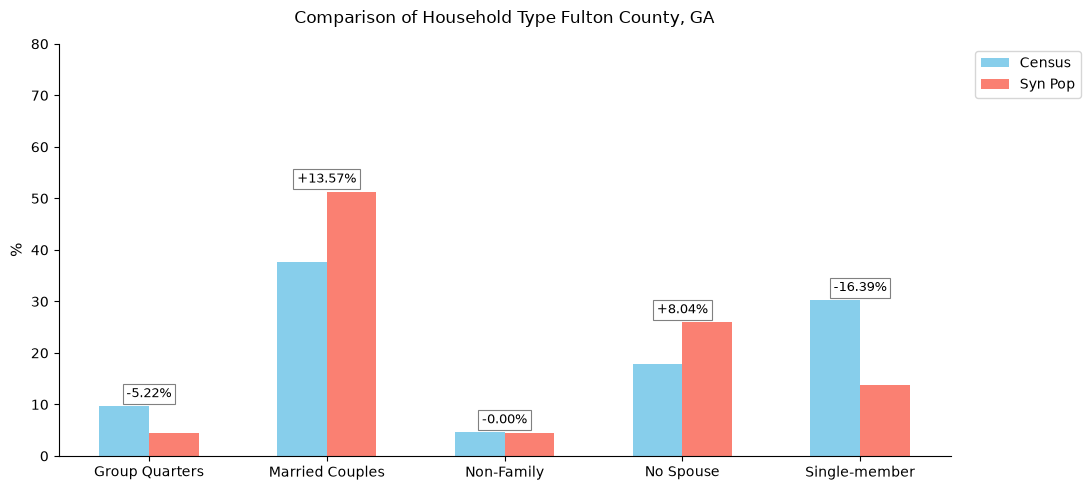

,hhtype,hhtype,census_pct,syn_pct
0,GQ,Group Quarters,9.626902,4.406246
1,MC,Married Couples,37.712322,51.286372
2,NF,Non-Family,4.550810,4.547804
3,NS,No Spouse,17.874325,25.918436
4,SM,Single-member,30.235641,13.841141


In [167]:
# Fulton County, GA
# 2. Plot distribution
helper.generate_side_by_side_plot(tract_hhtype_1300100, syn_indvs_spatial_1300100, 'Fulton County, GA')

In [150]:
# Load fresh
tract_hhtype_2503302 = pd.read_csv("synthpop_data/acs_marginals/2503302/tract_hhtype.csv")
tract_hhtype_2503302_t = tract_hhtype_2503302.set_index('geoid').T.reset_index().rename(columns={'index':'hhtype'}).rename_axis(None, axis=1)
tract_hhtype_2503302_t['count_census'] = tract_hhtype_2503302_t.drop('hhtype', axis=1).sum(axis=1)
tract_hhtype_2503302_t['perc_census'] = tract_hhtype_2503302_t['count_census'].apply(lambda x: 100 * x/sum(tract_hhtype_2503302_t['count_census']))
tract_hhtype_2503302_t[['hhtype', 'count_census', 'perc_census']]

,hhtype,count_census,perc_census
0,MC,15547,25.465177
1,NS,6280,10.286313
2,SM,25224,41.315600
3,NF,10972,17.971565
4,GQ,3029,4.961344


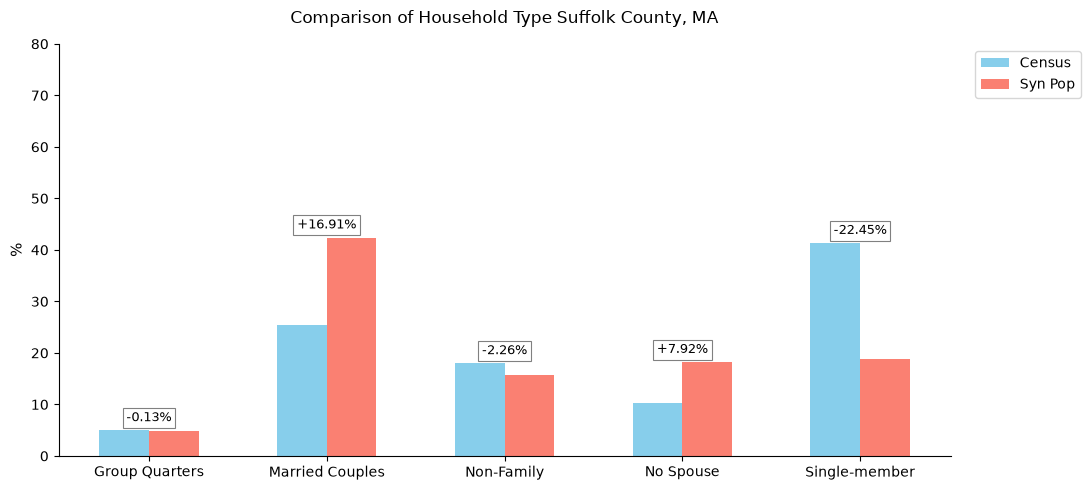

,hhtype,hhtype,census_pct,syn_pct,pct_diff
0,GQ,Group Quarters,4.961344,4.833705,-0.127639
1,MC,Married Couples,25.465177,42.378551,16.913374
2,NF,Non-Family,17.971565,15.715449,-2.256116
3,NS,No Spouse,10.286313,18.205050,7.918737
4,SM,Single-member,41.315600,18.867244,-22.448356


In [169]:
# Suffolk County, MA
helper.generate_side_by_side_plot(tract_hhtype_2503302, syn_indvs_spatial_2503302, 'Suffolk County, MA')
perc_hhtype_2503302 = syn_indvs_spatial_2503302.groupby('hhtype').agg('count').reset_index()[['hhtype', 'HHID']].rename(columns={'HHID': 'count_syn'})
perc_hhtype_2503302['perc_syn'] = perc_hhtype_2503302['count_syn'].apply(lambda x: 100 * x/len(syn_indvs_spatial_2503302))
# print('Synthetic Pop, Suffolk, MA (Example from j4sonli)')
# suffolk_hhtype_prop_df = pd.merge(perc_hhtype_2503302, tract_hhtype_2503302_t[['hhtype', 'count_census', 'perc_census']])
# suffolk_hhtype_prop_df['diff'] = suffolk_hhtype_prop_df.apply(lambda row: row['perc_syn'] - row['perc_census'], axis=1)
# display(suffolk_hhtype_prop_df[['count_census', 'count_syn',
#                                 'perc_census', 'perc_syn', 'diff']])

,hhtype,count,perc
0,GQ,7774,4.833705
1,MC,68157,42.378551
2,NF,25275,15.715449
3,NS,29279,18.205050
4,SM,30344,18.867244


In [ ]:
# Plot hhtype distrubtion (side-by-side barchart)
helper.process_census_data
helper.generate_side_by_side_plot


# Suffolk, MA (SynPop)

In [31]:
syn_hhs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_hhs_spatial_2503302-example.csv")
syn_indvs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_indvs_spatial_2503302-example.csv")

syn_indvs_spatial_2503302.head()

C:\Users\nicho\AppData\Local\Temp\ipykernel_27504\3597390117.py:1: DtypeWarning: Columns (0: nchil, 1: i_age, 2: i_sex, 3: race_, 4: i_eth, 5: i_inc, 6: emply, 7: edu_q) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_hhs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_hhs_spatial_2503302-example.csv")
C:\Users\nicho\AppData\Local\Temp\ipykernel_27504\3597390117.py:2: DtypeWarning: Columns (0: nchil) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_indvs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_indvs_spatial_2503302-example.csv")


,HHID,INDVID,tenur,hhinc,nwork,ncars,nchil,hhsiz,i_age,i_sex,...,i_eth,i_inc,emply,indus,edu_q,hhtype,puma,i_sex_i_age,emply_prox,geoid
0,1,1,Owned with mortgage or loan,>150K,2,2+,0,2,18-35,Female,...,Hispanic origin,>100K,Civilian employed,7,Middle school,MC,2503302,Female.18-35,Employed,250250706002
1,1,2,Owned with mortgage or loan,>150K,2,2+,0,2,36-50,Male,...,No Hispanic origin,>100K,Civilian employed,0,Master's,MC,2503302,Male.36-50,Employed,250250706002
2,2,3,Rented,1-25K,0,1,0,2,51-70,Female,...,Hispanic origin,1-25K,Not in labor force,0,Some college,MC,2503302,Female.51-70,Not in labor force,250250702001
3,2,4,Rented,1-25K,0,1,0,2,36-50,Female,...,Hispanic origin,1-25K,Not in labor force,8,High school or GED,MC,2503302,Female.36-50,Not in labor force,250250702001
4,3,5,Rented,51-75K,2,1,0,2,36-50,Female,...,Hispanic origin,26-50K,Civilian employed,9,High school or GED,MC,2503302,Female.36-50,Employed,250250107022


In [40]:
syn_indvs_spatial_2503302.shape

(160829, 21)